# Coding Session 11 · Lab W11

A probability forecast needs a record behind it. A decision also needs the consequences of each possible outcome. We reuse W10's table and scoring operations, then combine conditional probabilities in a separate practice scenario. The full assignment recommendation remains your own work.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def load_course_csv(name):
    candidates = [Path("data") / name, Path("wk11_forecasts_and_calibration/data") / name]
    for path in candidates:
        if path.exists():
            return pd.read_csv(path)
    url = ("https://raw.githubusercontent.com/albertostefanelli/"
           "DSPC_coding_sessions/master/wk11_forecasts_and_calibration/data/" + name)
    return pd.read_csv(url)

In [2]:
rec = load_course_csv("analyst_record.csv")
assert rec["forecast"].between(0, 1).all() and rec["won"].isin([0, 1]).all()
assert rec["race_id"].is_unique
print(rec.shape)
rec.head()

(150, 5)


,race_id,year,office,forecast,won
0,3,2018,City Council,0.60,1
1,8,2018,City Council,0.35,0
2,9,2018,School Board,0.90,1
3,10,2018,School Board,0.35,0
4,11,2018,City Council,0.40,0


## 1. Read the record and one calibration band

Source: Josh Kalla's [W11 teaching data](https://github.com/joshuakalla/data_science_campaigns_26/tree/main/weeks/wk11_forecasts_and_calibration). The included file is unchanged from the course reference; see [data provenance](https://github.com/albertostefanelli/DSPC_coding_sessions/blob/master/wk11_forecasts_and_calibration/data/README.md). Treat it as the course's teaching case, not an independently verified archive of real forecasts.

| Column | Unit |
| :--- | :--- |
| `race_id`, `year`, `office` | One forecasted race and its recorded context. |
| `forecast` | Forecast probability that the named candidate wins, from 0 to 1. |
| `won` | Whether that candidate won, coded 1 or 0. |

Begin with a different band from the lab's worked example. Compare its mean forecast with its fraction won. A small discrepancy in a small group may be sampling variation.

In [3]:
band = rec.loc[rec["forecast"].between(0.25, 0.45)]
pd.Series({"races": len(band), "mean_forecast": band["forecast"].mean(),
           "fraction_won": band["won"].mean()})

races            46.000000
mean_forecast     0.353261
fraction_won      0.326087
dtype: float64

### Build a calibration table

`pd.cut` makes groups; `groupby(...).agg(...)` calculates their summaries. These bins differ from the problem set so you practice the operation rather than copy its result. Right-closed intervals put an exact boundary in the bin ending there; `include_lowest=True` keeps zero.

**Write code after this demonstration:** create a new table using five equal-width bins. Include the mean forecast, realized frequency, and number of races. Check that the counts cover every race. Read the bin containing exactly 0.60 before interpreting a 60% forecast.

In [4]:
rec["practice_bin"] = pd.cut(rec["forecast"], [0, 0.25, 0.5, 0.75, 1],
                              include_lowest=True)
calibration = rec.groupby("practice_bin", observed=True).agg(
    n=("won", "size"), forecast=("forecast", "mean"), frequency=("won", "mean")
)
calibration["gap_pp"] = 100 * (calibration["forecast"] - calibration["frequency"])
assert calibration["n"].sum() == len(rec)
calibration.round(3)

,n,forecast,frequency,gap_pp
practice_bin,,,,
"(-0.001, 0.25]",37,0.178,0.162,1.622
"(0.25, 0.5]",41,0.396,0.366,3.049
"(0.5, 0.75]",47,0.682,0.638,4.362
"(0.75, 1.0]",25,0.864,0.720,14.400


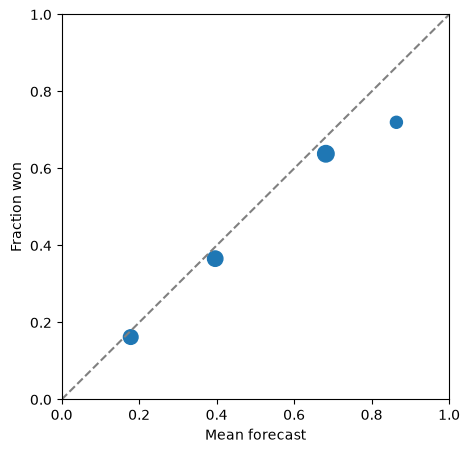

In [5]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot([0, 1], [0, 1], "--", color="gray")
ax.scatter(calibration["forecast"], calibration["frequency"], s=calibration["n"] * 3)
ax.set(xlabel="Mean forecast", ylabel="Fraction won", xlim=(0, 1), ylim=(0, 1))
plt.show()

**Interpret:** a point below the diagonal indicates overprediction within that bin. Do not infer that every individual forecast was too high, or that a few noisy bins prove systematic bias. Different offices, years, and local contexts may require different evidence.



## 2. Brier score and an honest baseline

Brier score averages `(forecast - won) ** 2`; lower is better. Run the supplied code and interpret it. The full-record base rate below is a **retrospective descriptive benchmark**. Because it uses all realized outcomes, it is not a deployable forecasting rule.

The additional chronological check estimates a constant using earlier races only and evaluates both forecasts and that constant on later races. We do not refit the analyst's forecasts or claim this small record proves future performance.

In [6]:
def brier(probability, outcome):
    return float(np.mean((probability - outcome) ** 2))

print("Analyst, full record:", round(brier(rec["forecast"], rec["won"]), 4))
print("Retrospective constant:", round(brier(rec["won"].mean(), rec["won"]), 4))
years = sorted(rec["year"].unique())
cutoff = years[len(years) // 2]
earlier = rec.loc[rec["year"] < cutoff]
later = rec.loc[rec["year"] >= cutoff]
assert len(earlier) and len(later)
print("Earlier/later rows:", len(earlier), len(later), "cutoff:", cutoff)
print("Analyst, later races:", round(brier(later["forecast"], later["won"]), 4))
print("Earlier-rate baseline:", round(brier(earlier["won"].mean(), later["won"]), 4))

Analyst, full record: 0.2117
Retrospective constant: 0.2484
Earlier/later rows: 76 74 cutoff: 2021
Analyst, later races: 0.1916
Earlier-rate baseline: 0.2484


**Explain:** how can a forecaster beat the constant baseline while overpredicting in some bins? Why is classification accuracy alone insufficient? Before applying a record to a new race, inspect whether the relevant probability range and context are represented.



## 3. From conditional probabilities to a decision

This is an **illustrative practice scenario**, with different inputs from the assignment. An organization cares about the expected share of a proposal implemented. There are two exhaustive primary outcomes, A and B. The general-election win probabilities are conditional on each candidate winning the primary; proposal shares are conditional on winning office.

Multiplying along a path gives its expected contribution; adding mutually exclusive paths gives the total. A 0.05 change in the probability of a primary win is five probability points, not five points of vote share.

In [7]:
practice = pd.DataFrame({
    "candidate": ["A", "B"],
    "primary_probability": [0.55, 0.45],
    "general_given_primary": [0.50, 0.60],
    "proposal_given_office": [0.50, 0.90],
})
practice["contribution"] = (practice["primary_probability"]
                            * practice["general_given_primary"]
                            * practice["proposal_given_office"])
def neutral_value():
    return float((practice["primary_probability"]
                  * practice["general_given_primary"]
                  * practice["proposal_given_office"]).sum())

print("Neutral expected share:", round(neutral_value(), 4))
practice

Neutral expected share: 0.3805


,candidate,primary_probability,general_given_primary,proposal_given_office,contribution
0,A,0.55,0.5,0.5,0.1375
1,B,0.45,0.6,0.9,0.2430


### Write a function whose inputs match the story

Endorsing B may transfer `shift` probability from A to B and reduce A's willingness to implement the proposal. Hold the other inputs fixed so the comparison is interpretable. These are assumptions, not estimates from the analyst record.

In [8]:
def endorsement_value(shift, a_share_after=0.35):
    inputs = practice.set_index("candidate")
    a, b = inputs.loc["A"], inputs.loc["B"]
    if not np.isclose(a["primary_probability"] + b["primary_probability"], 1):
        raise ValueError("primary probabilities must sum to one")
    if not 0 <= shift <= a["primary_probability"]:
        raise ValueError("shift must leave valid primary probabilities")
    if not 0 <= a_share_after <= 1:
        raise ValueError("proposal share must be between 0 and 1")
    return ((a["primary_probability"] - shift) * a["general_given_primary"] * a_share_after
            + (b["primary_probability"] + shift) * b["general_given_primary"]
            * b["proposal_given_office"])

pd.DataFrame({"shift_probability_points": [0, 4, 8, 12],
              "endorse_expected_share": [endorsement_value(s) for s in [0, 0.04, 0.08, 0.12]],
              "neutral_expected_share": neutral_value()})

,shift_probability_points,endorse_expected_share,neutral_expected_share
0,0,0.33925,0.3805
1,4,0.35385,0.3805
2,8,0.36845,0.3805
3,12,0.38305,0.3805


### Break-even: connect a small change to a threshold

For a linear decision function, the initial shortfall divided by the gain from one probability point gives the required number of points. First practice that idea on a separate arithmetic example: action X starts 0.018 behind and gains 0.003 expected proposal share per point; it catches up after 6 points.

**You write the decision code:** calculate `neutral_value() - endorsement_value(0)` and the difference between `endorsement_value(0.01)` and `endorsement_value(0)`. Divide them. Check the resulting threshold by converting points back to a probability and passing it to the function. Verify that it lies within the feasible range 0–55 points. If the per-point gain is zero or negative, division alone does not identify a feasible endorsement threshold.

In [9]:
# Worked arithmetic with separate practice numbers.
shortfall_example = 0.018
per_point_example = 0.003
print("Example break-even:", shortfall_example / per_point_example, "points")

# Your code in a new cell: compute and verify the endorsement threshold.

Example break-even: 5.999999999999999 points


## 4. Sensitivity: what information might change the action?

Run the supplied scenario sweep. Keep A's unendorsed proposal share fixed at 0.50 while varying its share after the endorsement. This changes the cost of antagonizing A, not both sides of the comparison. Read the action column for a fixed hypothetical shift; then write code to calculate a threshold for each row.

In [10]:
assumed_shift = 0.08
sensitivity = pd.DataFrame({"a_share_after": [0.50, 0.40, 0.30, 0.20]})
sensitivity["endorse_value"] = [endorsement_value(assumed_shift, s)
                                 for s in sensitivity["a_share_after"]]
sensitivity["neutral_value"] = neutral_value()
sensitivity["action_at_assumed_shift"] = np.where(
    sensitivity["endorse_value"] > neutral_value(), "endorse B", "stay neutral or indifferent"
)
sensitivity

,a_share_after,endorse_value,neutral_value,action_at_assumed_shift
0,0.5,0.4037,0.3805,endorse B
1,0.4,0.3802,0.3805,stay neutral or indifferent
2,0.3,0.3567,0.3805,stay neutral or indifferent
3,0.2,0.3332,0.3805,stay neutral or indifferent


**Additional practice:** change the assumed probability shift, then edit one `general_given_primary` value in the `practice` input table and rerun the notebook from that table onward. Both `neutral_value()` and `endorsement_value()` read that same table, keeping the two scenarios consistent. State which input changed, which remained fixed, and whether your action changes. Identify one uncertain input worth measuring and a value that would change your recommendation. The analyst's forecast quality matters, but it does not estimate the causal effect of your endorsement.

**Check your work:** every path uses the right conditional probabilities; shifts preserve probabilities summing to one; the threshold is expressed in probability points; your calibration table counts every race. Restart and run the notebook before interpreting the results.